# 📓 01_flood_event_exploration.ipynb

## Summary

In this notebook, I explored and cleaned the **major flood event dataset for Bhutan**. The main steps included:

- ✅ Loading and inspecting the cleaned CSV of major flash flood events  
- ✅ Converting date strings to proper `datetime` format  
- ✅ Extracting `year`, `month`, and `day` for temporal analysis  
- ✅ Exploring the distribution of `EventType` and identifying flash floods vs general floods
- ✅ Visualizing flood trends over time (yearly and monthly frequency)  
- ✅ Mapping flood occurrences by district and location   
- ✅ Saving the processed flood dataset to parquet for further analysis (e.g., correlation with ERA5 weather features)

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

### Load the bhutan flood dataset

In [2]:
# Define relative path from the flood_analysis folder
data_path = os.path.join("..", "..", "data", "Major_Flash_Flood_Events_Bhutan_CLEANED.csv")

# Load the CSV
flood_df = pd.read_csv(data_path)

# Preview the first few rows
print("✅ Loaded flood data with shape:", flood_df.shape)
flood_df.head()


✅ Loaded flood data with shape: (55, 9)


,EventID,Date,EventType,District,Location,Latitude,Longitude,Fatalities,Description
0,FF2022_01,07/07/2022,Flood,Samdrup Jongkhar,Samdrup Jongkhar,26.8055,91.5036,0,Urban flooding after heavy rainfall
1,FF2022_02,07/07/2022,Flash Flood,Mongar,Mongar town,27.2700,91.2400,0,Flash flood
2,FF2022_03,07/07/2022,Flash Flood,Wangduephodrang,Chuzomsa,27.5494,89.8969,0,Flash flood
3,FF2022_04,07/07/2022,Flash Flood,Mongar,Gyalpozhing,27.2676,91.1931,0,Flash flood
4,FF2022_05,07/07/2022,Flash Flood,Trashigang,Trashigang town,27.3332,91.5540,0,Flash flood


In [3]:
# Convert Date to datetime
flood_df["Date"] = pd.to_datetime(flood_df["Date"], format="%d/%m/%Y")

# Extract year, month, day for temporal analysis
flood_df["Year"] = flood_df["Date"].dt.year
flood_df["Month"] = flood_df["Date"].dt.month
flood_df["Day"] = flood_df["Date"].dt.day

# Preview
print(flood_df.dtypes)
flood_df.head()

EventID                object
Date           datetime64[ns]
EventType              object
District               object
Location               object
Latitude              float64
Longitude             float64
Fatalities              int64
Description            object
Year                    int32
Month                   int32
Day                     int32
dtype: object


,EventID,Date,EventType,District,Location,Latitude,Longitude,Fatalities,Description,Year,Month,Day
0,FF2022_01,2022-07-07,Flood,Samdrup Jongkhar,Samdrup Jongkhar,26.8055,91.5036,0,Urban flooding after heavy rainfall,2022,7,7
1,FF2022_02,2022-07-07,Flash Flood,Mongar,Mongar town,27.2700,91.2400,0,Flash flood,2022,7,7
2,FF2022_03,2022-07-07,Flash Flood,Wangduephodrang,Chuzomsa,27.5494,89.8969,0,Flash flood,2022,7,7
3,FF2022_04,2022-07-07,Flash Flood,Mongar,Gyalpozhing,27.2676,91.1931,0,Flash flood,2022,7,7
4,FF2022_05,2022-07-07,Flash Flood,Trashigang,Trashigang town,27.3332,91.5540,0,Flash flood,2022,7,7


In [4]:
# Show unique values and their counts
event_type_counts = flood_df["EventType"].value_counts()
print(event_type_counts)

EventType
Flash Flood    30
Flood          25
Name: count, dtype: int64


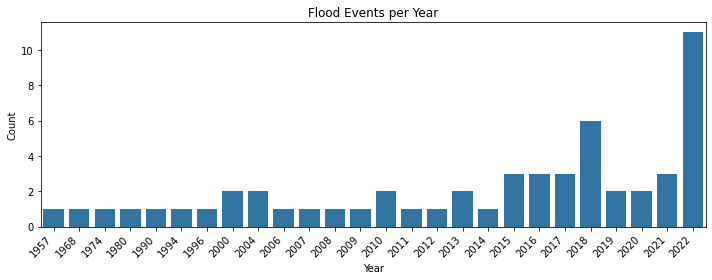

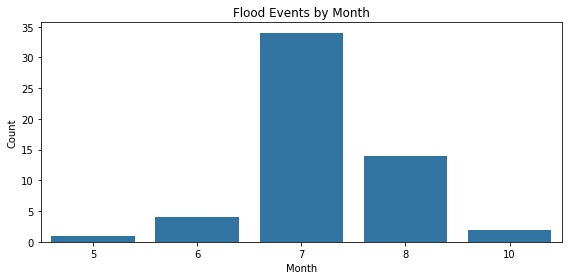

In [5]:
# Events per year
plt.figure(figsize=(10, 4))
sns.countplot(x="Year", data=flood_df)
plt.title("Flood Events per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')  # Rotate and align x-axis labels
plt.tight_layout()
plt.show()

# Events by month (seasonality)
plt.figure(figsize=(8, 4))
sns.countplot(x="Month", data=flood_df)
plt.title("Flood Events by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


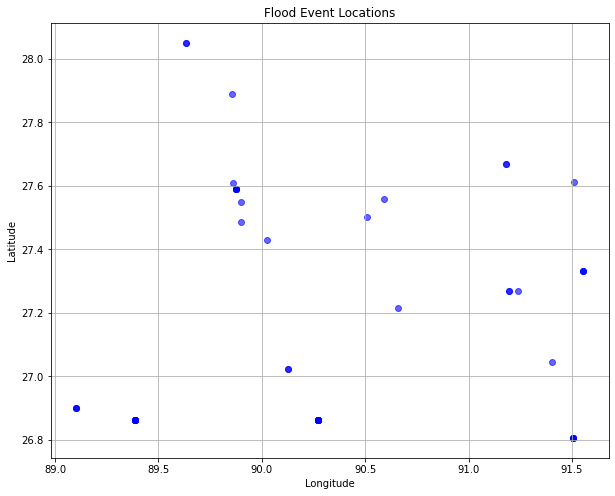

In [6]:
plt.figure(figsize=(10, 8))
plt.scatter(flood_df["Longitude"], flood_df["Latitude"], c='blue', alpha=0.6)
plt.title("Flood Event Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

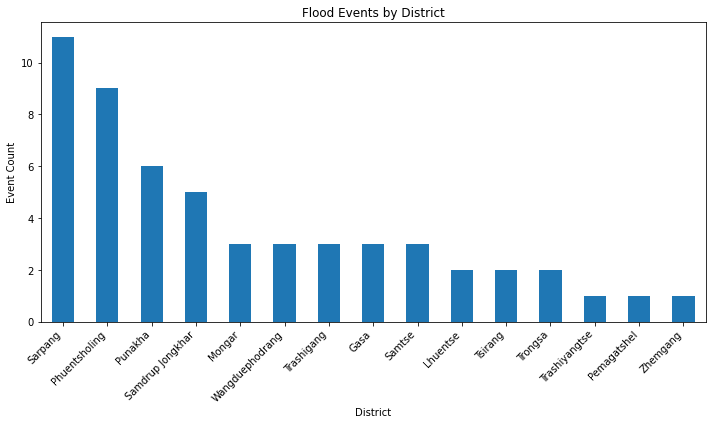

In [7]:
flood_df["District"].value_counts().plot(kind="bar", figsize=(10, 6))
plt.title("Flood Events by District")
plt.ylabel("Event Count")
plt.xlabel("District")
plt.xticks(rotation=45, ha='right')  # rotate and align x-axis labels
plt.tight_layout()
plt.show()

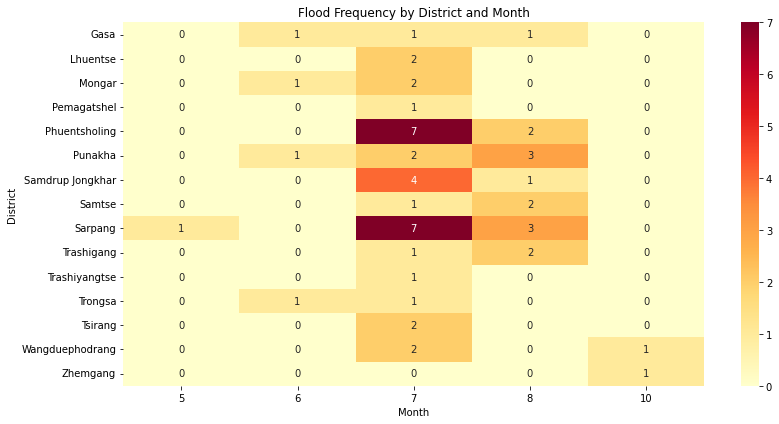

In [8]:
# Group by district and month
flood_df["Month"] = flood_df["Date"].dt.month
heatmap_data = flood_df.groupby(["District", "Month"]).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=True, fmt="d")
plt.title("Flood Frequency by District and Month")
plt.xlabel("Month")
plt.ylabel("District")
plt.tight_layout()
plt.show()


In [9]:
flood_df.to_parquet("../../data/cleaned_major_flood_events.parquet", index=False)
